# Track reconstruction — the validated two-start Fisher-GN

Reconstruct a single muon track (9-vector `[E, x,y,z, sinθ,cosθ, sinφ,cosφ, t0]`) from one
event's per-PMT **(charge, first-arrival time)** using the canonical
[`lucid.fitting`](../../lucid/fitting) API:

- **seeds:** energy scan → charge-grid vertex **‖** time-multilateration vertex
  (`seed_vertex_time`) → cone direction for each;
- **fit:** `fit_track_multistart` runs the Fisher-GN from both seeds and keeps the lower-loss
  basin (1% margin — the time seed rescues inward-pointing tracks the charge ring loses).

Validated over a 100-event GEANT4 campaign vs the exact gun truth: **vtx ~12 cm, dir ~1.0°,
energy unbiased, t0 ~0.5 ns RMS, 0 wanderers** (`../../campaign_recon/RESULTS.md`).

In [1]:
import sys; sys.path.append('../..')
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt

from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.detector_params import load_detector_params
from lucid.sources.event_io import read_photon_data_from_photonsim, pad_photon_data
from lucid.fitting import (ReconModel, fit_track_multistart, track_from_vec9, vec9_from_track,
                           vec9_dir, seed_vertex_time)
from lucid.optimization.grid_search import hierarchical_position_grid_search, get_detector_bounds
from lucid.optimization.utils.functions import (hierarchical_direction_search_cone,
                                                energy_scan_optimization)

GEOM = '../../config/SK_like_geom_config.json'
PHYS = '../../config/SK_like_physics_config.json'
# Path to a muon PhotonSim ROOT -- edit to your local data location. The files
# fetched by scripts/download_data.sh land under <repo>/data/water/muon/.
ROOT = 'data/water/muon/muon_gun_1050_MeV_100_events_fixed_energy.root'
K, NBUF, NPH, TTS = 8, 400_000, 250_000, 2.5
GRID = dict(n_cap=80, n_angular=120, n_height=80)
EV = 7   # which PhotonSim event to reconstruct

### 1. Build the forward — data simulator (truth photons) + per-photon predictor (the model)

In [2]:
det = generate_detector(GEOM); ND = len(det.all_points); POS = np.asarray(det.all_points)
bounds = get_detector_bounds(det)
dp = load_detector_params(PHYS, num_sensors=ND)
dp = dp._replace(response=dp.response._replace(tts=jnp.asarray(TTS)))   # 2.5 ns transit-time spread

data_sim = setup_event_simulator(GEOM, NBUF, temperature=None, K=K, is_data=True, hit_mode='realistic',
                                 physics_config=PHYS, default_detector_params=dp, particle='muon',
                                 wavelength_mode=True, apply_smearing=False, **GRID)
pred = setup_event_simulator(GEOM, NPH, temperature=0.1, K=K, hit_mode='per_photon', physics_config=PHYS,
                             default_detector_params=True, particle='muon', wavelength_mode=True,
                             pos_grad_threshold=K, n_grad_iters=K, **GRID)
model = ReconModel(pred, ND, sigma=TTS, delta=1.0)
print(f'{ND} PMTs')

10764 PMTs


### 2. Load an event and make the data

The muon gun fires from the **origin in +z**; we apply a fixed rotation+shift into the fiducial
volume, so the **exact truth** is that transform of `(origin, +z)` — no PCA needed (see
`../../campaign_recon/RESULTS.md`). `data_sim` then produces the per-PMT charge + first-arrival
time with realistic 2.5 ns TTS.

In [3]:
def rotax(u, deg):
    a = np.radians(deg); ca, sa = np.cos(a), np.sin(a); u = u / np.linalg.norm(u)
    ux = np.array([[0,-u[2],u[1]],[u[2],0,-u[0]],[-u[1],u[0],0]])
    return np.eye(3)*ca + sa*ux + (1-ca)*np.outer(u, u)

# fixed transform (reproducible): rotate ~50 deg about an in-plane axis, shift off-centre
R = rotax(np.array([0.3, 0.9, 0.]), 50.); sh = np.array([4.0, -3.0, 6.0]) * 100.   # cm
raw = read_photon_data_from_photonsim(ROOT, EV)
O = np.asarray(raw['photon_origins']).astype(float); c = O.mean(0)
raw = dict(raw); raw['photon_origins'] = (O - c) @ R.T + c + sh
raw['photon_directions'] = np.asarray(raw['photon_directions']).astype(float) @ R.T
vtx_true = ((np.zeros(3) - c) @ R.T + c + sh) / 100.0          # exact gun vertex (origin), m
dir_true = np.array([0., 0., 1.]) @ R.T                        # exact gun direction (+z)

pd, n = pad_photon_data(raw, NBUF)
dummy = track_from_vec9(jnp.array([1050.,0,0,0, 0.,1., 0.,1., 0.]))   # is_data ignores the track
c_, t_ = jax.lax.stop_gradient(data_sim(dummy, jax.random.PRNGKey(7000+EV), pd))
oc = np.asarray(c_); ot = np.where(oc > 0, np.asarray(t_), 0.)
print(f'event {EV}: {int((oc>0).sum())} PMTs lit, {oc.sum():.0f} total charge')
print(f'truth: vtx={np.round(vtx_true,2)} m  dir={np.round(dir_true,3)}')

event 7: 1797 PMTs lit, 4748 total charge
truth: vtx=[ 2.36 -2.45  6.85] m  dir=[ 0.727 -0.242  0.643]


### 3. Seed — energy scan, then charge-grid ‖ time-multilateration vertices, each + a cone direction

In [4]:
ocf, otf, POSf = jnp.asarray(oc), jnp.asarray(ot), jnp.asarray(POS)
e0 = energy_scan_optimization(pred, jnp.zeros(3), jnp.arccos(1/jnp.sqrt(3)), jnp.pi/4, 0.,
                              POSf, otf, ocf, (ocf, otf), 1000., 700., 12, 0)['best_energy']

def make_seed(vtx, t0g):
    c2 = hierarchical_direction_search_cone(pred, jnp.asarray(vtx), t0g, POSf, otf, ocf,
                                            (ocf, otf), e0, 3, 8, 90., 0.5, 0)
    dg = np.array([np.sin(c2['best_theta'])*np.cos(c2['best_phi']),
                   np.sin(c2['best_theta'])*np.sin(c2['best_phi']), np.cos(c2['best_theta'])])
    return vec9_from_track(e0, np.asarray(vtx), dg, t0=t0g)

p1 = hierarchical_position_grid_search(POSf, otf, ocf, jnp.zeros(3), 0., 0., bounds,
                                       n_div=5, t0_n_div=5, levels=6, verbosity=0)
seedA = make_seed(np.asarray(p1['best_position']), float(p1['best_t0']))   # charge-grid
seedB = make_seed(*seed_vertex_time(POS, oc, ot))                          # time-multilateration
print(f'seed A (charge) vtx err {np.linalg.norm(seedA[1:4]-vtx_true)*100:5.0f} cm')
print(f'seed B (time)   vtx err {np.linalg.norm(seedB[1:4]-vtx_true)*100:5.0f} cm')

seed A (charge) vtx err   137 cm
seed B (time)   vtx err   311 cm


### 4. Two-start Fisher-GN fit — keep the lower-loss basin

In [5]:
res, MS = fit_track_multistart(model, oc, ot, [seedA, seedB], nkeys=4, niters=250)
d_fit = vec9_dir(res)
print(f'winning seed: {"AB"[MS["which"]]}   (losses A={MS["losses"][0]:.0f} B={MS["losses"][1]:.0f})')
print(f'  vertex   err  {np.linalg.norm(res[1:4]-vtx_true)*100:6.2f} cm')
print(f'  direction err {np.degrees(np.arccos(np.clip(d_fit@dir_true,-1,1))):6.2f} deg')
print(f'  energy   bias {res[0]-1050.:+6.1f} MeV   t0 {res[8]:+5.2f} ns')

winning seed: A   (losses A=14823 B=14803)
  vertex   err   15.58 cm
  direction err   0.32 deg
  energy   bias  -12.5 MeV   t0 -0.13 ns


### 5. Convergence — the winning basin's per-iteration vertex/direction error

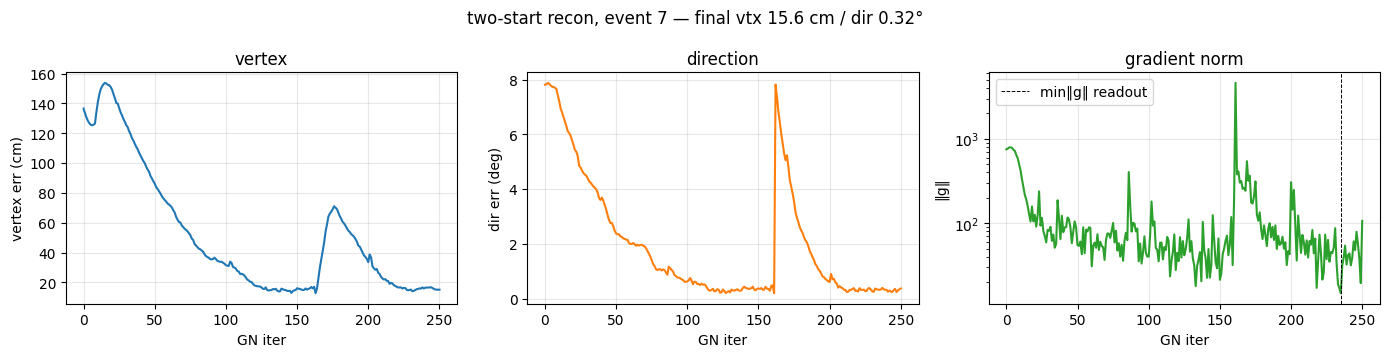

In [6]:
hist = MS['per_seed'][MS['which']][1]; tr = hist['traj']
it = np.arange(len(tr))
verr = np.linalg.norm(tr[:, 1:4] - vtx_true, axis=1) * 100
dirs = np.stack([vec9_dir(v) for v in tr]); aerr = np.degrees(np.arccos(np.clip(dirs @ dir_true, -1, 1)))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(it, verr); ax[0].set(xlabel='GN iter', ylabel='vertex err (cm)', title='vertex'); ax[0].grid(alpha=.3)
ax[1].plot(it, aerr, color='C1'); ax[1].set(xlabel='GN iter', ylabel='dir err (deg)', title='direction'); ax[1].grid(alpha=.3)
ax[2].semilogy(it, hist['gnorm'], color='C2'); ax[2].set(xlabel='GN iter', ylabel='‖g‖', title='gradient norm'); ax[2].grid(alpha=.3)
ax[2].axvline(hist['best_iter'], ls='--', c='k', lw=.7, label='min‖g‖ readout'); ax[2].legend()
fig.suptitle(f'two-start recon, event {EV} — final vtx {verr[hist["best_iter"]]:.1f} cm / dir {aerr[hist["best_iter"]]:.2f}°')
fig.tight_layout(); plt.show()